In [1]:
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

# load data

In [2]:
# load training dataset
train_path = "data/filled_dataset.csv"
chunk = pd.read_csv(train_path, chunksize=1000000)
df = pd.concat(chunk)

# data preparation

In [27]:
# split data based on search ids
train_groups, val_groups = train_test_split(df[['srch_id']].drop_duplicates(), test_size=0.1, random_state=42)

# split the actual data on those groups
train_data = df[df['srch_id'].isin(train_groups['srch_id'])]
val_data = df[df['srch_id'].isin(val_groups['srch_id'])]

# prepare X and y for train/val set
X_train = train_data.drop(columns=['click_bool', 'booking_bool', 'relevance', 'position', 'gross_bookings_usd'])
y_train = train_data['relevance']

X_val = val_data.drop(columns=['click_bool', 'booking_bool', 'relevance', 'position', 'gross_bookings_usd'])
y_val = val_data['relevance']

In [28]:
# create groups (for DMatrix)
train_group = train_data.groupby('srch_id').size().to_list()
val_group = val_data.groupby('srch_id').size().to_list()

dtrain = xgb.DMatrix(X_train, label=y_train)
dtrain.set_group(train_group)

dval = xgb.DMatrix(X_val, label=y_val)
dval.set_group(val_group)

# train model

In [29]:
params = {
    'objective': 'rank:pairwise',
    'eta': 0.1, # learning rate
    'gamma': 0.5, # minimum loss reduction required to further partition on a leaf node 
    'min_child_weight': 0.1, #  minimum sum of instance weights needed in a child
    'max_depth': 10, # max depth of the tree
    'eval_metric': 'ndcg' # 'map' for mean average precision; 'ndcg' for ndcg
}

In [30]:
epochs = 100
evals_result = {} # save results into dict
bst = xgb.train(params, dtrain, epochs, evals=[(dtrain, 'train'), (dval, 'val')],
                early_stopping_rounds=10, evals_result=evals_result, verbose_eval=True)

[0]	train-ndcg:0.47642	val-ndcg:0.46833
[1]	train-ndcg:0.48178	val-ndcg:0.47262
[2]	train-ndcg:0.48572	val-ndcg:0.47603
[3]	train-ndcg:0.48971	val-ndcg:0.47836
[4]	train-ndcg:0.49273	val-ndcg:0.48084
[5]	train-ndcg:0.49408	val-ndcg:0.48180
[6]	train-ndcg:0.49559	val-ndcg:0.48320
[7]	train-ndcg:0.49701	val-ndcg:0.48462
[8]	train-ndcg:0.49842	val-ndcg:0.48549
[9]	train-ndcg:0.49962	val-ndcg:0.48607
[10]	train-ndcg:0.50074	val-ndcg:0.48650
[11]	train-ndcg:0.50192	val-ndcg:0.48742
[12]	train-ndcg:0.50299	val-ndcg:0.48783
[13]	train-ndcg:0.50399	val-ndcg:0.48907
[14]	train-ndcg:0.50490	val-ndcg:0.48974
[15]	train-ndcg:0.50568	val-ndcg:0.49038
[16]	train-ndcg:0.50672	val-ndcg:0.49147
[17]	train-ndcg:0.50731	val-ndcg:0.49183
[18]	train-ndcg:0.50848	val-ndcg:0.49273
[19]	train-ndcg:0.50917	val-ndcg:0.49274
[20]	train-ndcg:0.50984	val-ndcg:0.49306
[21]	train-ndcg:0.51060	val-ndcg:0.49305
[22]	train-ndcg:0.51127	val-ndcg:0.49395
[23]	train-ndcg:0.51204	val-ndcg:0.49420
[24]	train-ndcg:0.51259	va

In [31]:
# save best model to save_models/
best_iteration = bst.best_iteration
best_score = bst.best_score
bst.save_model(f'save_models/best_model_{best_iteration}_score_{best_score:.2f}.model')

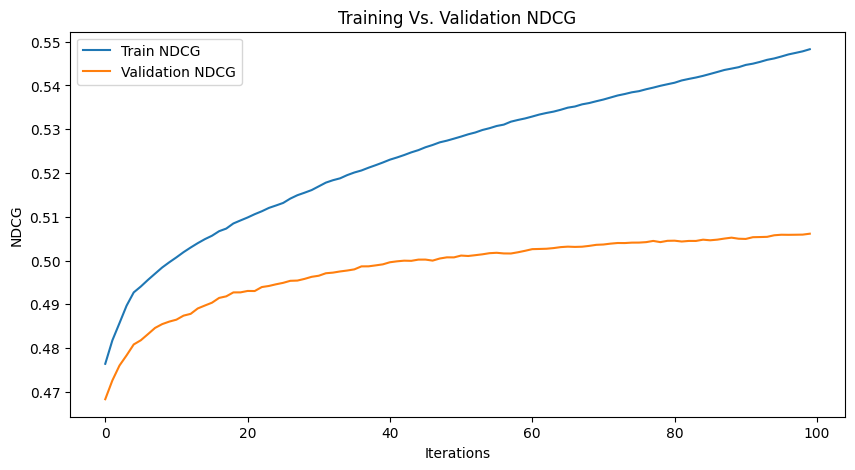

In [32]:
# plot training
train_evals = evals_result['train']['ndcg']
val_evals = evals_result['val']['ndcg']
plt.figure(figsize=(10, 5))
plt.plot(train_evals, label='Train NDCG')
plt.plot(val_evals, label='Validation NDCG')
plt.xlabel('Iterations')
plt.ylabel('NDCG')
plt.title('Training Vs. Validation NDCG')
plt.legend()
plt.ylim()
plt.show()

In [16]:
# validation set
preds = bst.predict(dval)
print(preds)

[-1.2444257  -0.06492182 -1.0223947  ... -1.6179527  -1.0324504
 -1.2767106 ]


Run model on the test_data:

In [24]:
# load test set
test_path = "data/test_set_VU_DM.csv"
chunk = pd.read_csv(test_path, chunksize=1000000)
test_df = pd.concat(chunk)

# copied from data_prep.ipynb
test_df = test_df.drop(['date_time','orig_destination_distance','comp1_rate','comp1_inv','comp1_rate_percent_diff','comp2_rate','comp2_inv','comp2_rate_percent_diff','comp3_rate','comp3_inv','comp3_rate_percent_diff','comp4_rate','comp4_inv','comp4_rate_percent_diff','comp5_rate','comp5_inv','comp5_rate_percent_diff','comp6_rate','comp6_inv','comp6_rate_percent_diff','comp7_rate','comp7_inv','comp7_rate_percent_diff','comp8_rate','comp8_inv','comp8_rate_percent_diff','srch_query_affinity_score', 'visitor_hist_starrating','visitor_hist_adr_usd'],axis=1)

In [33]:
dtest = xgb.DMatrix(test_df)

In [34]:
test_preds = bst.predict(dtest)
print(test_preds)

[ 0.8193526   0.8774924   0.64982516 ... -0.22957934  0.54004306
  0.95483506]


In [46]:
# add predictions as column
test_df['prediction'] = test_preds

grouped = test_df.groupby('srch_id').apply(lambda x: x.sort_values('prediction', ascending=False))

# Reset the index to flatten the DataFrame
grouped = grouped.reset_index(drop=True)

# Select the top 5 for each search_id
top5 = grouped.groupby('srch_id')

print(top5)

In [48]:
grouped[['srch_id', 'prop_id']].to_csv('kaggle_predictions/xgboost_predictions.csv', index=False, sep=',')